# PREPROCESSING 

---

CELL 1: Setup Environment

In [1]:
import os
import glob
import random
import warnings
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

# Menyembunyikan kotak merah (Warning) bawaan Jupyter agar output tetap bersih
warnings.filterwarnings("ignore")

# Setup path relatif dari lokasi notebookv2
BASE_DIR = Path("..") / "data"
RAW_DIR = BASE_DIR / "raw"

# Membuat folder isolasi khusus v2 agar tidak menimpa dataset lama
PROCESSED_V2_DIR = BASE_DIR / "processed_v2"
PATCHES_OUT_DIR = PROCESSED_V2_DIR / "patches"

# Buat folder output v2 jika belum tersedia
PATCHES_OUT_DIR.mkdir(parents=True, exist_ok=True)

PATH_JABAR = RAW_DIR / "jabar"
PATH_DKI = RAW_DIR / "dki_jakarta"
PATCH_SIZE = 256

print("✅ Setup Direktori & Import Library Berhasil!")
print(f"📂 Folder Raw Data: {RAW_DIR}")
print(f"📂 Folder Output Patches V2: {PATCHES_OUT_DIR}")

✅ Setup Direktori & Import Library Berhasil!
📂 Folder Raw Data: ..\data\raw
📂 Folder Output Patches V2: ..\data\processed_v2\patches


CELL 2: Koleksi Koordinat & Perekaman Angka Sensor

In [2]:
def scan_dan_koleksi_metadata(folder_path, patch_size=256):
    file_geotiff = glob.glob(os.path.join(folder_path, "*.tif"))
    records = []
    
    if not file_geotiff:
        print(f"⚠️ Folder tidak ditemukan atau kosong: {folder_path}")
        return records
        
    for file_path in file_geotiff:
        file_name = os.path.basename(file_path)
        print(f"🔍 Memindai koordinat citra (Multimodal V2): {file_name} ...")
        
        with rasterio.open(file_path) as src:
            idx_blue   = 1  # B2
            idx_green  = 2  # B3
            idx_red    = 3  # B4
            idx_nir    = 4  # B8
            idx_swir1  = 5  # B11
            idx_build  = 7  # building_mask
            idx_water  = 8  # water_recurrence
            idx_ndvi   = 9  # ndvi
            
            h, w = src.height, src.width
            stride = 32  # Overlap rapat khusus kelas slum
            
            for i in range(0, h - patch_size + 1, stride):
                for j in range(0, w - patch_size + 1, stride):
                    window = Window(j, i, patch_size, patch_size)
                    
                    patch_build = src.read(idx_build, window=window).astype(float)
                    patch_ndvi  = src.read(idx_ndvi, window=window).astype(float)
                    patch_water = src.read(idx_water, window=window).astype(float)
                    
                    if patch_ndvi.max() > 1.0: patch_ndvi /= 10000.0
                    if patch_build.max() > 1.0: patch_build /= 10000.0
                    if patch_water.max() > 1.0: patch_water /= 100.0 
                    
                    if np.mean(patch_build == 0) > 0.8 and np.mean(patch_ndvi == 0) > 0.8:
                        continue
                    
                    mean_build = np.mean(patch_build)
                    mean_ndvi  = np.mean(patch_ndvi)
                    mean_water_history = np.mean(patch_water)
                    
                    p_blue  = src.read(idx_blue, window=window).astype(float)
                    p_green = src.read(idx_green, window=window).astype(float)
                    p_red   = src.read(idx_red, window=window).astype(float)
                    p_nir   = src.read(idx_nir, window=window).astype(float)
                    p_swir1 = src.read(idx_swir1, window=window).astype(float)
                    
                    patch_mndwi = (p_green - p_swir1) / (p_green + p_swir1 + 1e-8)
                    patch_bsi   = ((p_swir1 + p_red) - (p_nir + p_blue)) / ((p_swir1 + p_red) + (p_nir + p_blue) + 1e-8)
                    
                    mean_mndwi = np.mean(patch_mndwi)
                    mean_bsi   = np.mean(patch_bsi)
                    
                    # Logika Penentuan Kelas
                    is_slum = (mean_build > 0.15 and mean_ndvi < 0.35 and mean_bsi > 0.02) or (mean_build > 0.12 and mean_water_history > 0.15)
                    
                    if is_slum:
                        kategori = "slum"
                    else:
                        kategori = "non-slum"
                        # Lewati jendela overlap untuk non-slum
                        if i % patch_size != 0 or j % patch_size != 0:
                            continue
                    
                    # 🎯 BAGIAN YANG DITAMBAHKAN: Perekaman Angka Tiap Sensor
                    records.append({
                        "src_file_path": file_path,
                        "src_file_name": file_name,
                        "row": i,
                        "col": j,
                        "category": kategori,
                        "mean_build": mean_build,
                        "mean_ndvi": mean_ndvi,
                        "mean_water": mean_water_history,
                        "mean_mndwi": mean_mndwi,
                        "mean_bsi": mean_bsi
                    })
                            
    return records

print("=== TAHAP 1: KOLEKSI KANDIDAT KOORDINAT PATCH V2 (MULTIMODAL) ===")
raw_records = []
raw_records.extend(scan_dan_koleksi_metadata(PATH_JABAR, PATCH_SIZE))
raw_records.extend(scan_dan_koleksi_metadata(PATH_DKI, PATCH_SIZE))

df_raw = pd.DataFrame(raw_records)
print(f"\n📊 Total kandidat koordinat terkumpul: {len(df_raw)} patch")
print(df_raw['category'].value_counts())

=== TAHAP 1: KOLEKSI KANDIDAT KOORDINAT PATCH V2 (MULTIMODAL) ===
🔍 Memindai koordinat citra (Multimodal V2): Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000000000-0000000000-001.tif ...
🔍 Memindai koordinat citra (Multimodal V2): Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000000000-0000011008-003.tif ...
🔍 Memindai koordinat citra (Multimodal V2): Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000000000-0000022016.tif ...
🔍 Memindai koordinat citra (Multimodal V2): Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000011008-0000000000.tif ...
🔍 Memindai koordinat citra (Multimodal V2): Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000011008-0000011008-005.tif ...
🔍 Memindai koordinat citra (Multimodal V2): Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000011008-0000022016.tif ...
🔍 Memindai koordinat citra (Multimodal V2): Dataset_Slum_NonSlum_DKI_JAKARTA_2025.tif ...

📊 Total kandidat koordinat terkumpul: 21008 patch
category
slum        12380
non-slum     8628
Name: count, dtype: int64


CELL 3: Balancer & Data Splitting

In [3]:
print("=== TAHAP 2: PROSES PENYEIMBANGAN KELAS & SPATIAL SPLITTING (ANTI-LEAKAGE) ===")
from sklearn.model_selection import GroupShuffleSplit

# 1. Penyeimbangan Kelas (Class Balancing)
df_slum = df_raw[df_raw['category'] == 'slum']
df_nonslum = df_raw[df_raw['category'] == 'non-slum']

target_balance = min(len(df_slum), len(df_nonslum))

df_slum_balanced = df_slum.sample(n=target_balance, random_state=42).reset_index(drop=True)
df_nonslum_balanced = df_nonslum.sample(n=target_balance, random_state=42).reset_index(drop=True)

# Gabungkan data yang sudah seimbang
df_balanced = pd.concat([df_slum_balanced, df_nonslum_balanced]).sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Fungsi Spatial Split menggunakan GroupShuffleSplit
def buat_spatial_split(df):
    # Pisahkan Train (80%) dan Sisa (20%) berdasarkan wilayah/gambar induk (src_file_name)
    gss_main = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
    train_idx, temp_idx = next(gss_main.split(df, groups=df['src_file_name']))
    
    df_train = df.iloc[train_idx].copy()
    df_temp = df.iloc[temp_idx].copy()
    
    # Pisahkan data sisa (Temp) menjadi Val (50%) dan Test (50%) berdasarkan wilayah
    gss_val = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
    val_idx, test_idx = next(gss_val.split(df_temp, groups=df_temp['src_file_name']))
    
    df_val = df_temp.iloc[val_idx].copy()
    df_test = df_temp.iloc[test_idx].copy()
    
    # Beri label split
    df_train['split'] = 'train'
    df_val['split'] = 'val'
    df_test['split'] = 'test'
    
    # Gabungkan kembali
    df_final = pd.concat([df_train, df_val, df_test]).reset_index(drop=True)
    return df_final

# 3. Terapkan Spatial Split ke dataset yang sudah seimbang
df_final_metadata = buat_spatial_split(df_balanced)

print("\n⚖️ Hasil Akhir Distribusi Skenario Balancer & Spatial Split:")
print(df_final_metadata.groupby(['split', 'category']).size())

# 4. Verifikasi Keamanan Leakage
train_src = set(df_final_metadata[df_final_metadata['split'] == 'train']['src_file_name'])
val_src = set(df_final_metadata[df_final_metadata['split'] == 'val']['src_file_name'])
bocor = train_src.intersection(val_src)

print("\n🚨 Pengecekan Keamanan (Data Leakage):")
print(f"Wilayah di Train : {len(train_src)} gambar induk")
print(f"Wilayah di Val   : {len(val_src)} gambar induk")
print(f"Jumlah Bocor     : {len(bocor)} wilayah overlap")

if len(bocor) == 0:
    print("✅ STATUS: AMAN! Tidak ada piksel yang menyeberang antar split.")
else:
    print("⚠️ STATUS: MASIH ADA KEBOCORAN!")

=== TAHAP 2: PROSES PENYEIMBANGAN KELAS & SPATIAL SPLITTING (ANTI-LEAKAGE) ===

⚖️ Hasil Akhir Distribusi Skenario Balancer & Spatial Split:
split  category
test   non-slum    1822
       slum         913
train  non-slum    5024
       slum        4862
val    non-slum    1782
       slum        2853
dtype: int64

🚨 Pengecekan Keamanan (Data Leakage):
Wilayah di Train : 5 gambar induk
Wilayah di Val   : 1 gambar induk
Jumlah Bocor     : 0 wilayah overlap
✅ STATUS: AMAN! Tidak ada piksel yang menyeberang antar split.


CELL 4: Pemotongan Fisik & Pembuatan Manifest Final

In [4]:
print("=== TAHAP 3: PEMOTONGAN FISIK & PENYIMPANAN EXTRA CHANNELS V2 ===")

metadata_saved_records = []

for idx, row in tqdm(df_final_metadata.iterrows(), total=len(df_final_metadata)):
    patch_id = f"patch_{row['category']}_{idx:05d}"
    nama_file_output = f"{patch_id}.tif"
    path_file_output = PATCHES_OUT_DIR / nama_file_output
    
    with rasterio.open(row['src_file_path']) as src:
        window_potong = Window(row['col'], row['row'], PATCH_SIZE, PATCH_SIZE)
        
        array_9_bands = src.read(window=window_potong)
        band_red = array_9_bands[2].astype(float)
        
        red_8bit = ((band_red - band_red.min()) / (band_red.max() - band_red.min() + 1e-8) * 255).astype(np.uint8)
        glcm = graycomatrix(red_8bit, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        contrast_map = graycoprops(glcm, 'contrast')[0, 0]
        array_glcm = np.full((1, PATCH_SIZE, PATCH_SIZE), contrast_map, dtype=np.float32)
        
        p_blue, p_green, p_red, p_nir, p_swir1 = array_9_bands[0], array_9_bands[1], array_9_bands[2], array_9_bands[3], array_9_bands[4]
        matrix_mndwi = np.expand_dims((p_green - p_swir1) / (p_green + p_swir1 + 1e-8), axis=0)
        matrix_bsi   = np.expand_dims(((p_swir1 + p_red) - (p_nir + p_blue)) / ((p_swir1 + p_red) + (p_nir + p_blue) + 1e-8), axis=0)
        
        final_multimodal_tensor = np.concatenate([array_9_bands, matrix_mndwi, matrix_bsi, array_glcm], axis=0)
        
        profil_baru = src.profile.copy()
        profil_baru.update({
            "height": PATCH_SIZE,
            "width": PATCH_SIZE,
            "count": 12,
            "dtype": 'float32',
            "transform": rasterio.windows.transform(window_potong, src.transform)
        })
        
        with rasterio.open(path_file_output, "w", **profil_baru) as dst:
            dst.write(final_multimodal_tensor.astype(np.float32))
            dst.descriptions = tuple(list(src.descriptions) + ['mndwi_calc', 'bsi_calc', 'glcm_contrast'])
            
    # 🎯 BAGIAN YANG DITAMBAHKAN: Membungkus semua angka fitur ke final CSV
    metadata_saved_records.append({
        "patch_id": patch_id,
        "patch_filename": nama_file_output,
        "source_img": row['src_file_name'],
        "origin_row": row['row'],
        "origin_col": row['col'],
        "category": row['category'],
        "split": row['split'],
        "mean_build": row['mean_build'],
        "mean_ndvi": row['mean_ndvi'],
        "mean_water": row['mean_water'],
        "mean_mndwi": row['mean_mndwi'],
        "mean_bsi": row['mean_bsi'],
        "glcm_contrast": contrast_map
    })

# Simpan Manifest dataset_metadata_final_v2.csv
df_csv_final = pd.DataFrame(metadata_saved_records)
output_csv_path = PROCESSED_V2_DIR / "dataset_metadata_final_v2.csv"
df_csv_final.to_csv(output_csv_path, index=False)

print("\n================ RANGKUMAN DATASET MULTIMODAL 12-BAND SUKSES ================")
print(f"✅ Setiap patch kini memiliki 12 kombinasi fitur spasial & spektral lengkap!")
print(f"💾 File CSV Final (beserta angka sensornya) sukses disimpan di: {output_csv_path}")
print("=========================================================================")

=== TAHAP 3: PEMOTONGAN FISIK & PENYIMPANAN EXTRA CHANNELS V2 ===


100%|██████████| 17256/17256 [46:51<00:00,  6.14it/s]  



================ RANGKUMAN DATASET MULTIMODAL 12-BAND SUKSES ================
✅ Setiap patch kini memiliki 12 kombinasi fitur spasial & spektral lengkap!
💾 File CSV Final (beserta angka sensornya) sukses disimpan di: ..\data\processed_v2\dataset_metadata_final_v2.csv


CELL 5: Visualisasi 12-Band Tensor

🖼️ Membaca, menormalisasi, dan memetakan 12-band patch satelit...


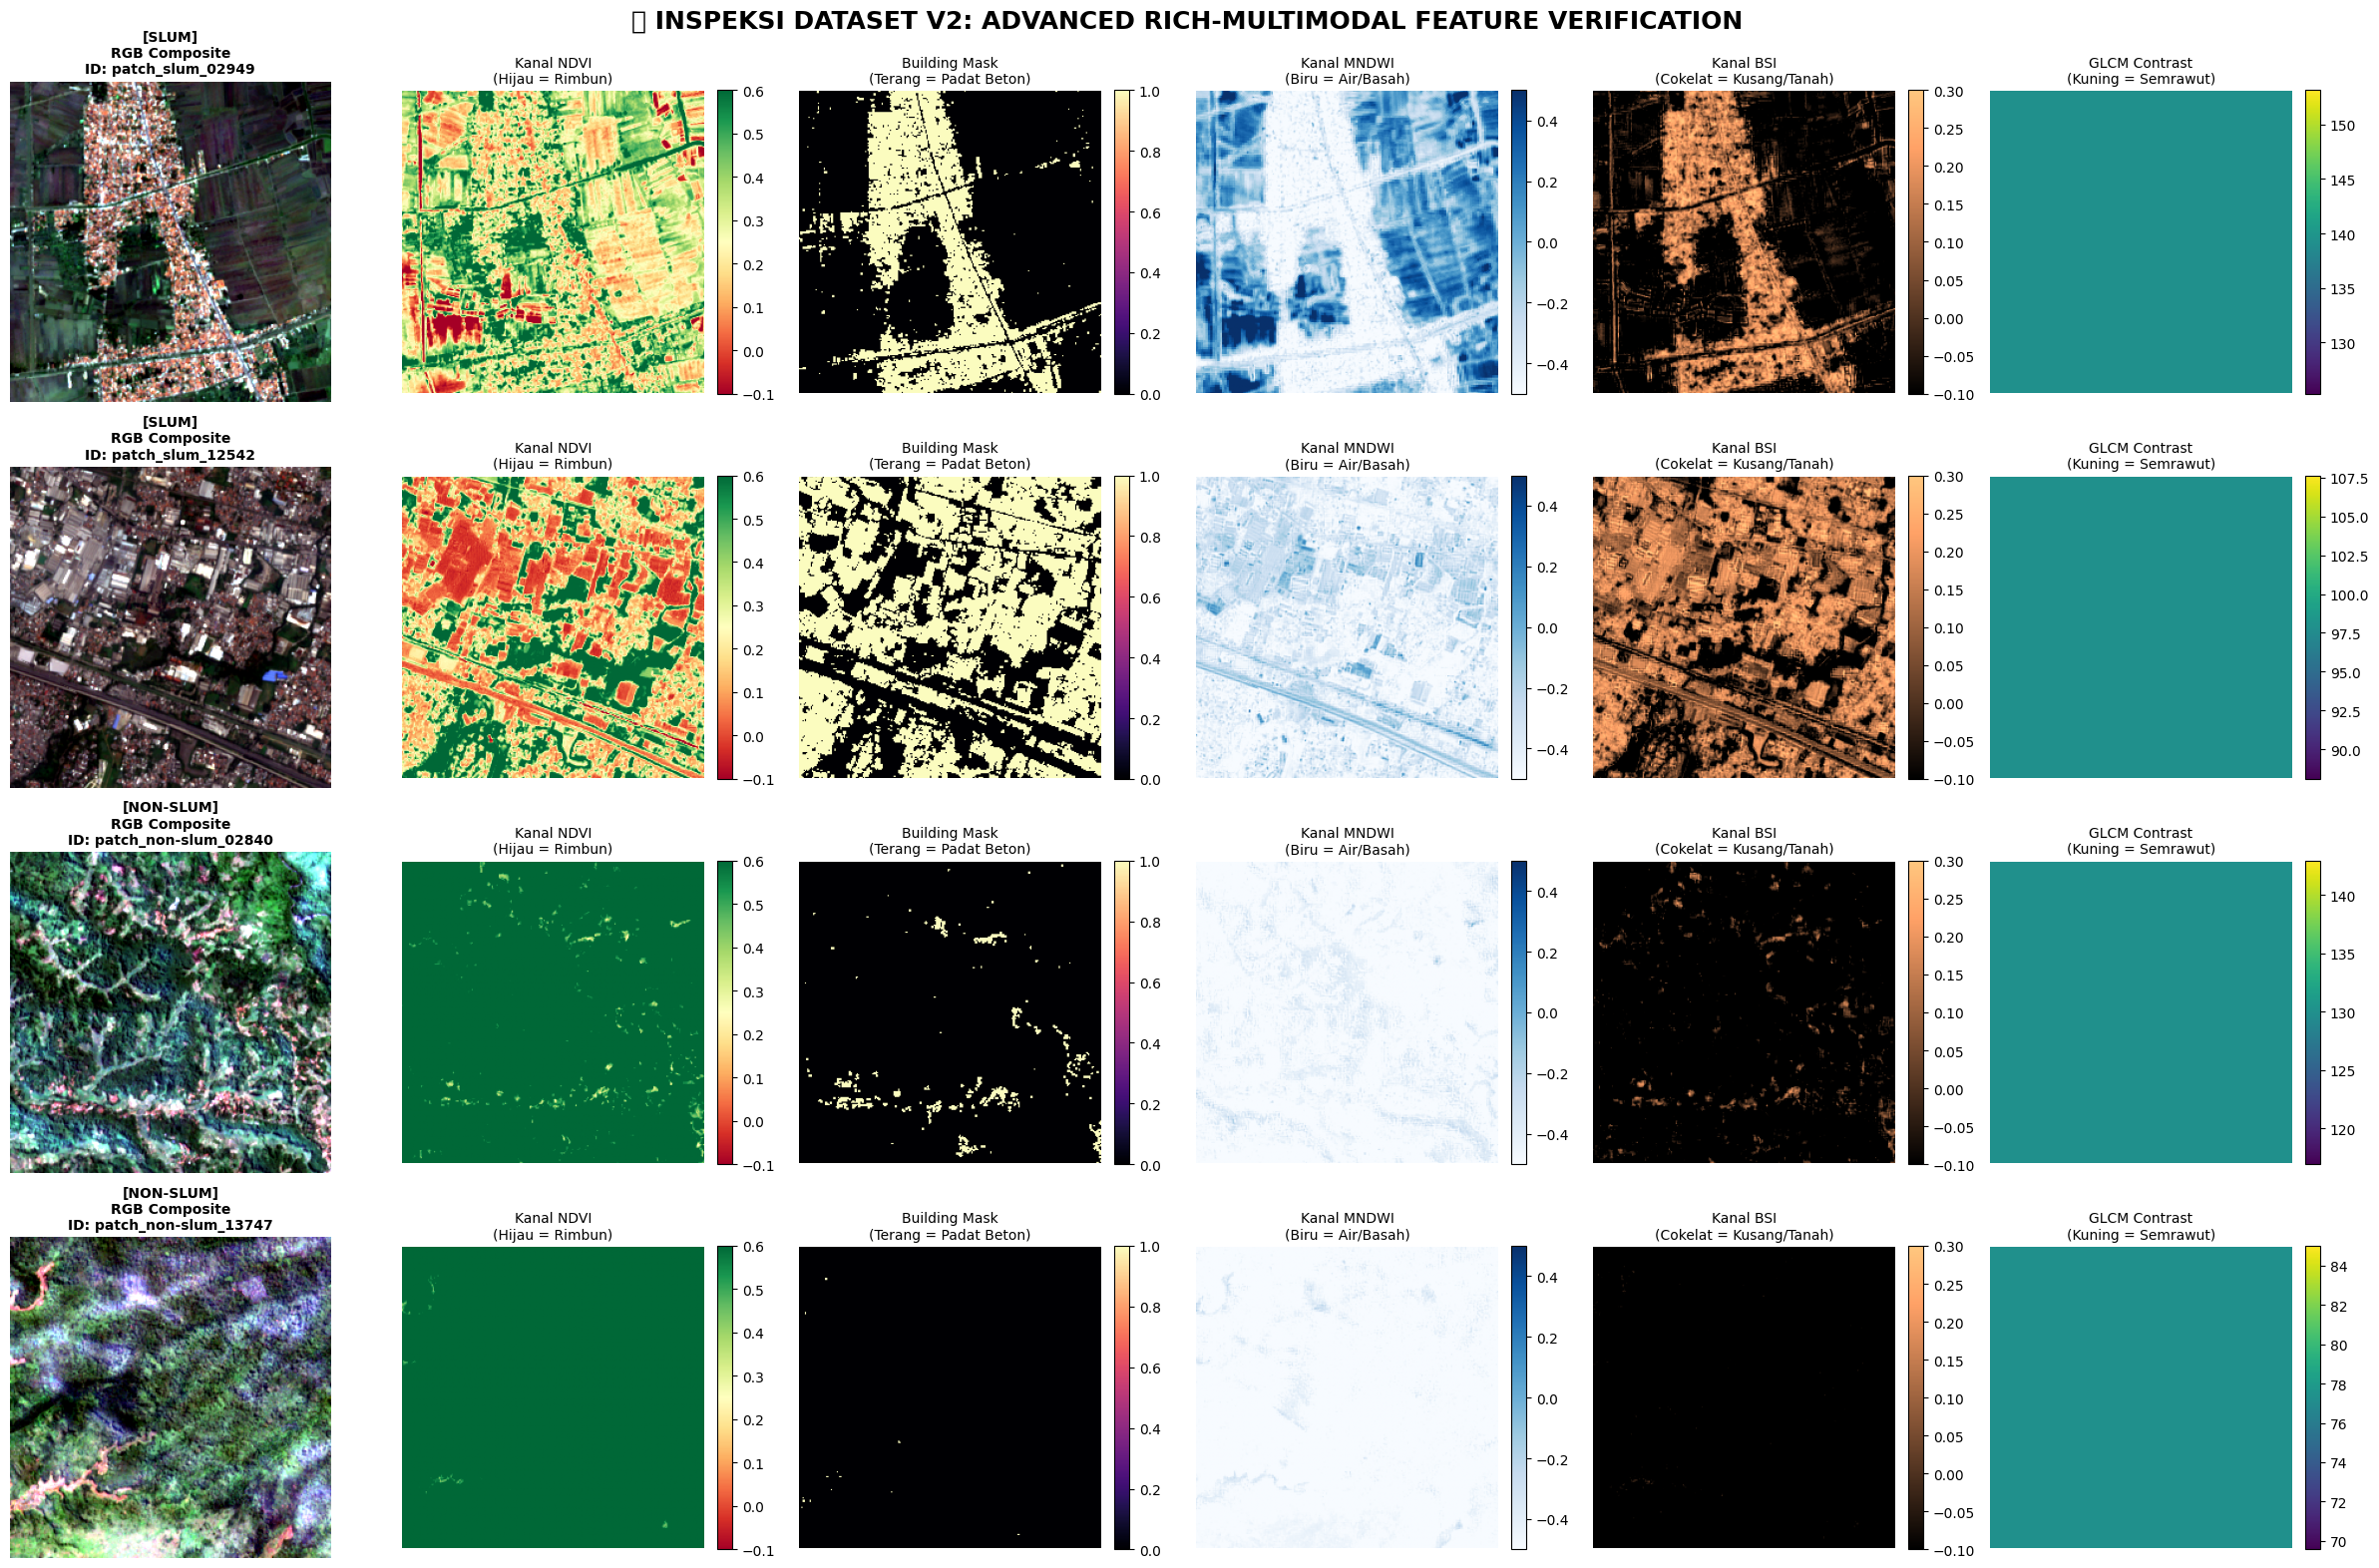

In [5]:
# 1. Load Manifest Metadata V2
CSV_PATH = PROCESSED_V2_DIR / "dataset_metadata_final_v2.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(f"⚠️ File metadata tidak ditemukan di: {CSV_PATH}. Jalankan Tahap Pemotongan V2 terlebih dahulu!")

df_meta = pd.read_csv(CSV_PATH)

# 2. Ambil sampel acak (2 Slum & 2 Non-Slum)
sample_slum = df_meta[df_meta['category'] == 'slum'].sample(n=2, random_state=42)
sample_nonslum = df_meta[df_meta['category'] == 'non-slum'].sample(n=2, random_state=42)
df_samples = pd.concat([sample_slum, sample_nonslum]).reset_index(drop=True)

# 3. Setup Grid Plotting Baru (4 Sampel Gambar x 6 Kanal Fitur Ilmiah)
fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(24, 16))

print("🖼️ Membaca, menormalisasi, dan memetakan 12-band patch satelit...")

for idx, row in df_samples.iterrows():
    patch_path = PATCHES_OUT_DIR / row['patch_filename']
    
    with rasterio.open(patch_path) as src:
        band_names = src.descriptions
        
        # Pencarian Indeks Band secara Dinamis
        idx_build = band_names.index('building_mask') + 1 if 'building_mask' in band_names else 7
        idx_ndvi = band_names.index('ndvi') + 1 if 'ndvi' in band_names else 9
        idx_mndwi = band_names.index('mndwi_calc') + 1 if 'mndwi_calc' in band_names else 10
        idx_bsi = band_names.index('bsi_calc') + 1 if 'bsi_calc' in band_names else 11
        idx_glcm = band_names.index('glcm_contrast') + 1 if 'glcm_contrast' in band_names else 12
        
        img_rgb = src.read([1, 2, 3]) 
        img_build = src.read(idx_build)
        img_ndvi = src.read(idx_ndvi)
        img_mndwi = src.read(idx_mndwi)
        img_bsi = src.read(idx_bsi)
        img_glcm = src.read(idx_glcm)
        
        img_rgb_true = np.stack([img_rgb[2], img_rgb[1], img_rgb[0]], axis=-1).astype(float)
        
        for b in range(3):
            p2, p98 = np.percentile(img_rgb_true[:,:,b], (2, 98))
            img_rgb_true[:,:,b] = np.clip((img_rgb_true[:,:,b] - p2) / (p98 - p2 + 1e-8), 0, 1)
            
        if img_ndvi.max() > 1.0: img_ndvi /= 10000.0
        if img_build.max() > 1.0: img_build /= 10000.0
        
        ax_rgb = axes[idx, 0]
        ax_rgb.imshow(img_rgb_true)
        ax_rgb.set_title(f"[{row['category'].upper()}]\nRGB Composite\nID: {row['patch_id']}", fontsize=10, fontweight='bold')
        ax_rgb.axis('off')
        
        ax_ndvi = axes[idx, 1]
        im_ndvi = ax_ndvi.imshow(img_ndvi, cmap='RdYlGn', vmin=-0.1, vmax=0.6)
        ax_ndvi.set_title("Kanal NDVI\n(Hijau = Rimbun)", fontsize=10)
        ax_ndvi.axis('off')
        fig.colorbar(im_ndvi, ax=ax_ndvi, fraction=0.046, pad=0.04)
        
        ax_bld = axes[idx, 2]
        im_bld = ax_bld.imshow(img_build, cmap='magma', vmin=0, vmax=1)
        ax_bld.set_title("Building Mask\n(Terang = Padat Beton)", fontsize=10)
        ax_bld.axis('off')
        fig.colorbar(im_bld, ax=ax_bld, fraction=0.046, pad=0.04)
        
        ax_wtr = axes[idx, 3]
        im_wtr = ax_wtr.imshow(img_mndwi, cmap='Blues', vmin=-0.5, vmax=0.5)
        ax_wtr.set_title("Kanal MNDWI\n(Biru = Air/Basah)", fontsize=10)
        ax_wtr.axis('off')
        fig.colorbar(im_wtr, ax=ax_wtr, fraction=0.046, pad=0.04)
        
        ax_bsi = axes[idx, 4]
        im_bsi = ax_bsi.imshow(img_bsi, cmap='copper', vmin=-0.1, vmax=0.3)
        ax_bsi.set_title("Kanal BSI\n(Cokelat = Kusang/Tanah)", fontsize=10)
        ax_bsi.axis('off')
        fig.colorbar(im_bsi, ax=ax_bsi, fraction=0.046, pad=0.04)
        
        ax_glcm = axes[idx, 5]
        im_glcm = ax_glcm.imshow(img_glcm, cmap='viridis')
        ax_glcm.set_title("GLCM Contrast\n(Kuning = Semrawut)", fontsize=10)
        ax_glcm.axis('off')
        fig.colorbar(im_glcm, ax=ax_glcm, fraction=0.046, pad=0.04)

plt.suptitle("🔬 INSPEKSI DATASET V2: ADVANCED RICH-MULTIMODAL FEATURE VERIFICATION", fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

CELL 6: Ekspor Output Angka Murni per Sensor (BARU!)

In [6]:
print("=== TAHAP 4: EKSPOR DATASET CSV PER SENSOR ===")

# Buat sub-folder khusus agar file CSV-nya tidak berantakan
CSV_PER_SENSOR_DIR = PROCESSED_V2_DIR / "csv_per_sensor"
CSV_PER_SENSOR_DIR.mkdir(parents=True, exist_ok=True)

# Daftar pemetaan nama file CSV output dan nama kolom fiturnya
daftar_sensor = {
    "build": "mean_build",
    "ndvi": "mean_ndvi",
    "water_history": "mean_water",
    "mndwi": "mean_mndwi",
    "bsi": "mean_bsi",
    "glcm": "glcm_contrast"
}

# Kolom wajib yang harus selalu ada di setiap CSV sebagai identitas
kolom_identitas = ['patch_id', 'category', 'split']

for nama_file, nama_kolom in daftar_sensor.items():
    # Filter hanya kolom identitas dan 1 kolom sensor yang sedang diproses
    df_sensor_khusus = df_csv_final[kolom_identitas + [nama_kolom]].copy()
    
    # Ekspor menjadi CSV terpisah
    path_csv = CSV_PER_SENSOR_DIR / f"{nama_file}.csv"
    df_sensor_khusus.to_csv(path_csv, index=False)
    
    print(f"✅ Berhasil mengekspor: {nama_file}.csv")

print(f"\n📂 Semua file CSV per sensor telah tersimpan rapi di dalam folder:")
print(f"   👉 {CSV_PER_SENSOR_DIR}")

=== TAHAP 4: EKSPOR DATASET CSV PER SENSOR ===
✅ Berhasil mengekspor: build.csv
✅ Berhasil mengekspor: ndvi.csv
✅ Berhasil mengekspor: water_history.csv
✅ Berhasil mengekspor: mndwi.csv
✅ Berhasil mengekspor: bsi.csv
✅ Berhasil mengekspor: glcm.csv

📂 Semua file CSV per sensor telah tersimpan rapi di dalam folder:
   👉 ..\data\processed_v2\csv_per_sensor
